SVM Accuracy: 0.9473684210526315


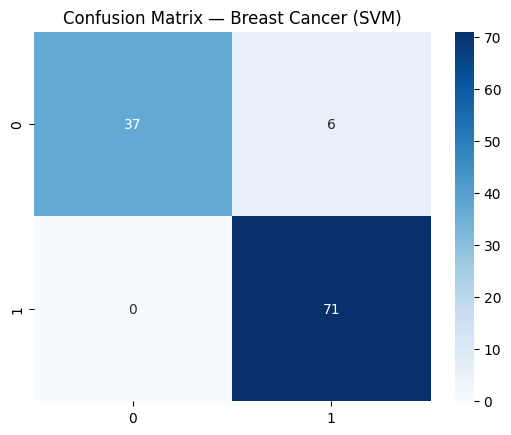

In [6]:
# ============================================================
# PART 1 — BREAST CANCER CLASSIFICATION (SVM)
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
cancer = load_breast_cancer()
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_cancer["target"] = cancer.target

# Train-test split
X = df_cancer.drop("target", axis=1)
y = df_cancer["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train SVM
svm_model = SVC()
svm_model.fit(X_train, y_train)

# Predict
y_pred = svm_model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("SVM Accuracy:", accuracy)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Breast Cancer (SVM)")
plt.show()

Synthetic Concrete Dataset Created


,cement,slag,flyash,water,superplasticizer,coarse_aggregate,fine_aggregate,strength
0,249.816048,192.609494,20.624774,141.961558,21.217159,874.053172,903.305278,21.511894
1,480.285723,25.241989,180.510581,156.216744,4.576171,1016.760379,609.834767,35.047044
2,392.797577,48.488614,101.050474,143.011363,17.288651,1149.178334,608.849421,28.655104
3,339.463394,269.566257,165.291493,131.531329,18.201451,1092.889955,729.444088,47.285886
4,162.407456,181.928718,64.009920,135.682663,12.723920,1122.624459,795.457276,16.392246



Random Forest MSE: 24.526110073487104
Random Forest R² Score: 0.8499379006738803


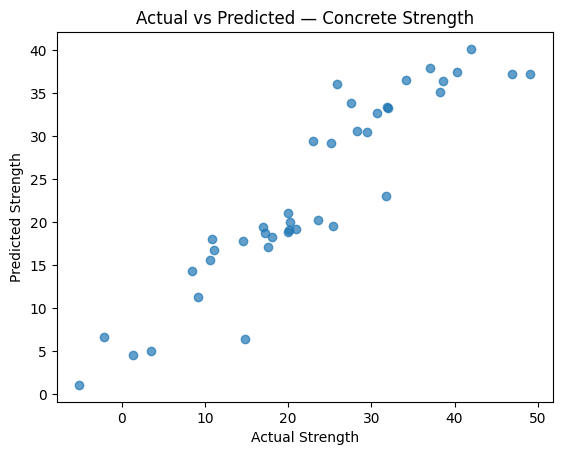

In [7]:
# ============================================================
# PART 2 — CONCRETE STRENGTH REGRESSION (Synthetic Dataset)
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create a synthetic dataset with same columns as UCI Concrete dataset
np.random.seed(42)

df_concrete = pd.DataFrame({
    "cement": np.random.uniform(100, 500, 200),
    "slag": np.random.uniform(0, 300, 200),
    "flyash": np.random.uniform(0, 200, 200),
    "water": np.random.uniform(120, 250, 200),
    "superplasticizer": np.random.uniform(0, 30, 200),
    "coarse_aggregate": np.random.uniform(800, 1200, 200),
    "fine_aggregate": np.random.uniform(600, 1000, 200),
})

# Synthetic target (strength)
df_concrete["strength"] = (
    0.1 * df_concrete["cement"]
    + 0.05 * df_concrete["slag"]
    - 0.08 * df_concrete["water"]
    + np.random.normal(0, 5, 200)
)

print("Synthetic Concrete Dataset Created")
display(df_concrete.head())

# Train-test split
X = df_concrete.drop("strength", axis=1)
y = df_concrete["strength"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nRandom Forest MSE:", mse)
print("Random Forest R² Score:", r2)

# Plot actual vs predicted
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs Predicted — Concrete Strength")
plt.show()